In [54]:
import numpy as np
import pandas as pd

In [55]:
_hz = 104 # hz
_dt = 1.0 / _hz

M_PI = np.pi
DEG_TO_RAD = M_PI / 180.0
RAD_TO_DEG = 180.0 / M_PI
G_TO_MS2 = 9.80665
MG_TO_MS2 = G_TO_MS2 / 1000.0

    # float default_gyro_bias[3] = {-0.398, 0.587, 0.770};
    # float default_acce_bias[3] = {-79.406,204.207,989.005};
_calibration_gyro_bias = np.array([-0.398, 0.587, 0.770])
_calibration_acc_bias = np.array([-79.406,204.207,989.005])

_accel_filtered_prev = [0.0, 0.0, 0.0]
_gyro_filtered_prev = [0.0, 0.0, 0.0]

_ref_yaw_deg = 0
_ref_pitch_deg = 0
_ref_roll_deg = 0

_prev_yaw_deg = 0.0
_prev_pitch_deg = 0.0
_prev_roll_deg = 0.0

_simple_yaw_deg = 0.0
_simple_pitch_deg = 0.0
_simple_roll_deg = 0.0

_comp_yaw_deg = 0.0
_comp_pitch_deg = 0.0
_comp_roll_deg = 0.0


In [56]:
def printState():
    global _simple_yaw_deg, _simple_pitch_deg, _simple_roll_deg
    global _comp_yaw_deg, _comp_pitch_deg, _comp_roll_deg
    global _prev_yaw_deg, _prev_pitch_deg, _prev_roll_deg
    global _ref_yaw_deg, _ref_pitch_deg, _ref_roll_deg
    print(f"Simple: Yaw: {_simple_yaw_deg:.2f}, Pitch: {_simple_pitch_deg:.2f}, Roll: {_simple_roll_deg:.2f}")
    print(f"Comp:   Yaw: {_comp_yaw_deg:.2f}, Pitch: {_comp_pitch_deg:.2f}, Roll: {_comp_roll_deg:.2f}")
    print(f"Prev:   Yaw: {_prev_yaw_deg:.2f}, Pitch: {_prev_pitch_deg:.2f}, Roll: {_prev_roll_deg:.2f}")
    print(f"Ref:    Yaw: {_ref_yaw_deg:.2f}, Pitch: {_ref_pitch_deg:.2f}, Roll: {_ref_roll_deg:.2f}")

def resetState():
    global _simple_yaw_deg, _simple_pitch_deg, _simple_roll_deg
    global _comp_yaw_deg, _comp_pitch_deg, _comp_roll_deg
    global _prev_yaw_deg, _prev_pitch_deg, _prev_roll_deg
    global _ref_yaw_deg, _ref_pitch_deg, _ref_roll_deg
    _simple_yaw_deg = 0.0
    _simple_pitch_deg = 0.0
    _simple_roll_deg = 0.0
    _comp_yaw_deg = 0.0
    _comp_pitch_deg = 0.0
    _comp_roll_deg = 0.0
    _prev_yaw_deg = 0.0
    _prev_pitch_deg = 0.0
    _prev_roll_deg = 0.0

resetState()


In [57]:
def tiltAngleFromAccel(accel: list[float], axis: int):
    ax = accel[0] * MG_TO_MS2
    ay = accel[1] * MG_TO_MS2
    az = accel[2] * MG_TO_MS2
    angle_rad = 0.0
    if (axis == 0):
        angle_rad = np.atan2(ay, az)
    elif (axis == 1):
        angle_rad = np.atan2(-ax, np.sqrt(ay * ay + az * az))
    else:
        return 0.0
    return angle_rad * RAD_TO_DEG

def preprocessing(input: list[float], prev: list[float]) -> list[float]:
    output: list[float] = [0.0, 0.0, 0.0]
    alpha = 0.232
    for i in range(3):
        output[i] = alpha * input[i] + (1 - alpha) * prev[i]
        prev[i] = output[i]
    return output

def normalizeAngle(angle: float) -> float:
    while angle > 180.0:
        angle -= 360.0
    while angle < -180.0:
        angle += 360.0
    return angle

def convertToRelativeAngles(output: dict): # TODO: can we update this so that we can use the _ref_yaw_deg as list of segments of different on/off tests? The set up we have now does not work.
    global _ref_yaw_deg, _ref_pitch_deg, _ref_roll_deg
    output["yaw_deg"] = _ref_yaw_deg - output["yaw_deg"]
    output["pitch_deg"] = _ref_pitch_deg - output["pitch_deg"]
    output["roll_deg"] = _ref_roll_deg - output["roll_deg"]
    return output

def updateSimpleFilter(gyro_filtered: list[float], makeRelative=True):
    global _simple_yaw_deg, _simple_pitch_deg, _simple_roll_deg
    global _dt
    _simple_yaw_deg = _simple_yaw_deg + gyro_filtered[2] * _dt
    _simple_pitch_deg = _simple_pitch_deg + gyro_filtered[0] * _dt
    _simple_roll_deg = _simple_roll_deg + gyro_filtered[1] * _dt

    output = {}
    output['yaw_deg'] = normalizeAngle(_simple_yaw_deg)
    output['pitch_deg'] = normalizeAngle(_simple_pitch_deg)
    output['roll_deg'] = normalizeAngle(_simple_roll_deg)

    if makeRelative:
        output = convertToRelativeAngles(output)
    _simple_yaw_deg = output['yaw_deg']
    _simple_pitch_deg = output['pitch_deg']
    _simple_roll_deg = output['roll_deg']

def updateComplementaryFilter(accel_filtered: list[float], gyro_filtered: list[float], makeRelative=True):
    global _comp_yaw_deg, _comp_pitch_deg, _comp_roll_deg
    global _alpha, _dt
    acc_pitch_deg = tiltAngleFromAccel(accel_filtered, 0) 
    acc_roll_deg = tiltAngleFromAccel(accel_filtered, 1)  
    gyro_pitch_deg = _comp_pitch_deg + gyro_filtered[0] * _dt
    gyro_roll_deg = _comp_roll_deg + gyro_filtered[1] * _dt
    gyro_yaw_deg = _comp_yaw_deg + gyro_filtered[2] * _dt
    
    _alpha = 0.98 
    _comp_pitch_deg = _alpha * gyro_pitch_deg + (1. - _alpha) * acc_pitch_deg
    _comp_roll_deg = _alpha * gyro_roll_deg + (1. - _alpha) * acc_roll_deg
    _comp_yaw_deg = gyro_yaw_deg 
    
    output = {}
    output["yaw_deg"]  = normalizeAngle(_comp_yaw_deg)
    output["pitch_deg"]= normalizeAngle(_comp_pitch_deg)
    output["roll_deg"] = normalizeAngle(_comp_roll_deg)
    
    if makeRelative:
        output = convertToRelativeAngles(output)
    _comp_yaw_deg = output['yaw_deg']
    _comp_pitch_deg = output['pitch_deg']
    _comp_roll_deg = output['roll_deg']

    # //combination logic based on testing results:
    # // - Azimuth (yaw): Simple filter works better but can be noisy
    # // - Tilt (pitch/roll): Complementary filter has less drift
    
    # // Yaw: Use simple filter as primary, but validate with complementary filter
    # output.yaw_deg = _simple_yaw_deg;
    
    # // Check if complementary filter shows significant change
    # float yaw_diff = fabsf(_comp_yaw_deg - _prev_yaw_deg);
    # if (yaw_diff < 10.0f) { // Small change threshold
    #     // If complementary filter shows small change, trust simple filter
    #     output.yaw_deg = _simple_yaw_deg;
    # } else {
    #     // If complementary filter shows large change, use weighted average
    #     output.yaw_deg = 0.6f * _simple_yaw_deg + 0.4f * _comp_yaw_deg;
    # }
    
    # // Pitch and Roll: Use complementary filter as primary (less drift)
    # output.pitch_deg = _comp_pitch_deg;
    # output.roll_deg = _comp_roll_deg;
    
    # // Normalize final angles to [0,180]
    # output.yaw_deg = _normalizeAngle(output.yaw_deg);
    # output.pitch_deg = _normalizeAngle(output.pitch_deg);
    # output.roll_deg = _normalizeAngle(output.roll_deg);

def combineFilters():
    global _simple_yaw_deg, _simple_pitch_deg, _simple_roll_deg
    global _comp_yaw_deg, _comp_pitch_deg, _comp_roll_deg
    global _prev_yaw_deg, _prev_pitch_deg, _prev_roll_deg

    output = {}
    output["yaw_deg"] = _simple_yaw_deg
    yaw_diff: float = abs(_comp_yaw_deg - _prev_yaw_deg)
    if (yaw_diff < 10.0): # Small change threshold
        output["yaw_deg"] = _simple_yaw_deg
    else:
        output["yaw_deg"] = 0.6 * _simple_yaw_deg + 0.4 * _comp_yaw_deg
    
    output["pitch_deg"] = _comp_pitch_deg
    output["roll_deg"] = _comp_roll_deg

    output["yaw_deg"] = normalizeAngle(output["yaw_deg"])
    output["pitch_deg"] = normalizeAngle(output["pitch_deg"])
    output["roll_deg"] = normalizeAngle(output["roll_deg"])
    return output








In [58]:
def preupdate(accel_raw: list[float], gyro_raw: list[float], timestamp: int) -> dict:
    global _accel_filtered_prev, _gyro_filtered_prev
    global _prev_yaw_deg, _prev_pitch_deg, _prev_roll_deg
    global _simple_yaw_deg, _simple_pitch_deg, _simple_roll_deg
    global _comp_yaw_deg, _comp_pitch_deg, _comp_roll_deg
    global _calibration_acc_bias, _calibration_gyro_bias
    global _ref_yaw_deg, _ref_pitch_deg, _ref_roll_deg


    output = {}
    output['timestamp'] = timestamp

    # Apply calibration biases
    accel_corrected = np.zeros_like(accel_raw)
    gyro_corrected = np.zeros_like(gyro_raw)
    for i in range(len(accel_raw)):
        accel_corrected[i] = accel_raw[i] - _calibration_acc_bias[i]
        gyro_corrected[i] = gyro_raw[i] - _calibration_gyro_bias[i]

    accel_filtered: list[float] = np.zeros(3)
    gyro_filtered: list[float] = np.zeros(3)

    # Apply low-pass filter
    accel_filtered = preprocessing(accel_corrected, _accel_filtered_prev)
    gyro_filtered = preprocessing(gyro_corrected, _gyro_filtered_prev)

    updateSimpleFilter(gyro_filtered, makeRelative=False)

    updateComplementaryFilter(accel_filtered, gyro_filtered, makeRelative=False)
    
    output = combineFilters()
    
    _prev_yaw_deg = output["yaw_deg"]
    _prev_pitch_deg = output["pitch_deg"]
    _prev_roll_deg = output["roll_deg"]




def update(accel_raw: list[float], gyro_raw: list[float], timestamp: int) -> dict:
    global _accel_filtered_prev, _gyro_filtered_prev
    global _prev_yaw_deg, _prev_pitch_deg, _prev_roll_deg
    global _simple_yaw_deg, _simple_pitch_deg, _simple_roll_deg
    global _comp_yaw_deg, _comp_pitch_deg, _comp_roll_deg
    global _calibration_acc_bias, _calibration_gyro_bias

    output = {}
    output['timestamp'] = timestamp


    # Apply calibration biases
    accel_corrected = np.zeros_like(accel_raw)
    gyro_corrected = np.zeros_like(gyro_raw)
    for i in range(len(accel_raw)):
        accel_corrected[i] = accel_raw[i] - _calibration_acc_bias[i]
        gyro_corrected[i] = gyro_raw[i] - _calibration_gyro_bias[i]

    accel_filtered: list[float] = np.zeros(3)
    gyro_filtered: list[float] = np.zeros(3)

    # Apply low-pass filter
    accel_filtered = preprocessing(accel_corrected, _accel_filtered_prev)
    gyro_filtered = preprocessing(gyro_corrected, _gyro_filtered_prev)

    updateSimpleFilter(gyro_filtered)

    updateComplementaryFilter(accel_filtered, gyro_filtered)
    
    output = combineFilters()
    
    _prev_yaw_deg = output["yaw_deg"]
    _prev_pitch_deg = output["pitch_deg"]
    _prev_roll_deg = output["roll_deg"]
    

     

In [59]:
df = pd.read_csv("raw_data_output_altitude.csv")
df.head()

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,0.743,-18,990,58,5670,-4270,-490
1,0.743,-18,991,56,140,-490,-140
2,0.743,-16,989,58,420,-490,-210
3,0.743,-17,988,58,420,-490,-140
4,0.743,-17,991,59,350,-490,-140


In [60]:
def segmentation_gaps(df):
    # Detect time gaps for segmentation
    gap_threshold = 5.0  # seconds
    timestamps = df["timestamp"].values
    gaps = np.where(np.abs(np.diff(timestamps)) > gap_threshold)[0]

    # Create segment boundaries
    segment_bounds = []
    start = 0
    for gap_idx in gaps:
        segment_bounds.append((start, gap_idx + 1))
        start = gap_idx + 1
    segment_bounds.append((start, len(df)))

    print(f"Found {len(segment_bounds)} segments:")
    for i, (start, end) in enumerate(segment_bounds):
        duration = df.iloc[end-1]['timestamp'] - df.iloc[start]['timestamp']
        print(f"  Segment {i}: samples {start}-{end-1}, duration {duration:.1f}s")

    # Map to test configuration if available
    segments = []
    for i, (start, end) in enumerate(segment_bounds):
        segment_data = df.iloc[start:end].copy()
        segments.append({
            'test_id': i,
            'data': segment_data.reset_index(),
            'start_idx': start,
            'end_idx': end
        })
    return segments

In [61]:
required_cols = ["timestamp", "accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# Convert to numeric
for col in required_cols[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# Drop rows with NaN values in required columns
df = df.dropna(subset=required_cols)
# Convert from EDN (East-Down-North) to NED (North-East-Down) coordinate system
# This ensures Az (Z-axis) is aligned with gravity vector
# EDN -> NED transformation:
# X_EDN -> Y_NED (East -> East)  
# Y_EDN -> -Z_NED (Down -> -Down)
# Z_EDN -> X_NED (North -> North)

# Accelerometer conversion
accel_x_ned = df["accel_z"].copy()  # North (Z_EDN -> X_NED)
accel_y_ned = df["accel_x"].copy()  # East (X_EDN -> Y_NED)  
accel_z_ned = -df["accel_y"].copy() # Down (Y_EDN -> -Z_NED)

df["accel_x"] = accel_x_ned
df["accel_y"] = accel_y_ned
df["accel_z"] = accel_z_ned

# Gyroscope conversion (same transformation)
gyro_x_ned = df["gyro_z"].copy()  # North
gyro_y_ned = df["gyro_x"].copy()  # East
gyro_z_ned = -df["gyro_y"].copy() # Down

df["gyro_x"] = gyro_x_ned
df["gyro_y"] = gyro_y_ned
df["gyro_z"] = gyro_z_ned

segments = segmentation_gaps(df)

# # Process first 5 seconds of data (104 Hz * 5 sec = 520 samples) to get reference
# for segment in segments:
#     test_id, data, start_idx, end_idx = segment.values()
#     for i in range(start_idx, end_idx):
#             _ref_pitch_deg = []
            

#         update(
#             [data["accel_x"][i], data["accel_y"][i], data["accel_z"][i]],
#             [data["gyro_x"][i], data["gyro_y"][i], data["gyro_z"][i]],
#             data["timestamp"][i]
#         )
#         _ref_pitch_deg.append(_prev_pitch_deg)
#         _ref_roll_deg.append(_prev_roll_deg)
#         _ref_yaw_deg.append(_prev_yaw_deg)
#     printState()

Found 12 segments:
  Segment 0: samples 0-7068, duration 64.0s
  Segment 1: samples 7069-14048, duration 63.1s
  Segment 2: samples 14049-21043, duration 63.2s
  Segment 3: samples 21044-24877, duration 34.6s
  Segment 4: samples 24878-28643, duration 34.1s
  Segment 5: samples 28644-32543, duration 35.1s
  Segment 6: samples 32544-36583, duration 36.4s
  Segment 7: samples 36584-40743, duration 37.5s
  Segment 8: samples 40744-44419, duration 33.1s
  Segment 9: samples 44420-47983, duration 32.2s
  Segment 10: samples 47984-51803, duration 34.4s
  Segment 11: samples 51804-55614, duration 34.4s


In [62]:
segment_results = {}
for segment in segments:
    test_id, data, start_idx, end_idx = segment.values()
    
    simple = []
    comp = []
    prev = []
    ref = []
    for i in range(len(data)):
        if (104*5) > i:
            update(
                [data["accel_x"][i], data["accel_y"][i], data["accel_z"][i]],
                [data["gyro_x"][i], data["gyro_y"][i], data["gyro_z"][i]],
                data["timestamp"][i]
            )
            _ref_yaw_deg = _prev_yaw_deg
            _ref_pitch_deg = _prev_pitch_deg
            _ref_roll_deg = _prev_roll_deg
            continue
        update(
            [data["accel_x"][i], data["accel_y"][i], data["accel_z"][i]],
            [data["gyro_x"][i], data["gyro_y"][i], data["gyro_z"][i]],
            data["timestamp"][i]
        )
        simple.append([_simple_yaw_deg, _simple_pitch_deg, _simple_roll_deg])
        comp.append([_comp_yaw_deg, _comp_pitch_deg, _comp_roll_deg])
        prev.append([_prev_yaw_deg, _prev_pitch_deg, _prev_roll_deg])
        ref.append([_ref_yaw_deg, _ref_pitch_deg, _ref_roll_deg])
    simple = np.array(simple).T 
    comp = np.array(comp).T
    prev = np.array(prev).T
    ref = np.array(ref).T
    angle_delta = [abs(pr - rf) for (pr, rf) in zip(prev, ref)]
    results = {"simple": simple, "comp": comp, "prev": prev, "ref": ref, "delta": angle_delta}
    segment_results[test_id] = results
    resetState()



In [63]:
import matplotlib.pyplot as plt

In [64]:
def plot_raw(df, title=""):
    fig, axs = plt.subplots(2,3, figsize=(18,10), sharex=True)
    axs[0,0].plot(df["accel_x"], label="accel_x", alpha=0.7)
    axs[0,0].set_title("Accel X")
    axs[0,0].set_xlabel('Sample')
    axs[0,0].set_ylabel('g')
    axs[0,0].legend()
    
    axs[0,1].plot(df["accel_y"], label="accel_y", alpha=0.7)
    axs[0,1].set_title("Accel Y")
    axs[0,1].set_xlabel('Sample')
    axs[0,1].set_ylabel('g')
    axs[0,1].legend()

    axs[0,2].plot(df["accel_z"], label="accel_z", alpha=0.7)
    axs[0,2].set_title("Accel Z")
    axs[0,2].set_xlabel('Sample')
    axs[0,2].set_ylabel('g')
    axs[0,2].legend()

    axs[1,0].plot(df["gyro_x"], label="gyro_x", alpha=0.7)
    axs[1,0].set_title("Gyro X")
    axs[1,0].set_xlabel('Sample')
    axs[1,0].set_ylabel('deg/s')
    axs[1,0].legend()

    axs[1,1].plot(df["gyro_y"], label="gyro_y", alpha=0.7)
    axs[1,1].set_title("Gyro Y")
    axs[1,1].set_xlabel('Sample')
    axs[1,1].set_ylabel('deg/s')
    axs[1,1].legend()

    axs[1,2].plot(df["gyro_z"], label="gyro_z", alpha=0.7)
    axs[1,2].set_title("Gyro Z")
    axs[1,2].set_xlabel('Sample')
    axs[1,2].set_ylabel('deg/s')
    axs[1,2].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_angles(yaw, pitch, roll, title=""):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
    axs[0].plot(yaw, label='Yaw', alpha=0.7)
    axs[0].set_title('Yaw')
    axs[0].set_xlabel('Sample')
    axs[0].set_ylabel('Degrees')
    axs[0].legend()

    axs[1].plot(pitch, label='Pitch', alpha=0.7)
    axs[1].set_title('Pitch')
    axs[1].set_xlabel('Sample')
    axs[1].set_ylabel('Degrees')
    axs[1].legend()

    axs[2].plot(roll, label='Roll', alpha=0.7)
    axs[2].set_title('Roll')
    axs[2].set_xlabel('Sample')
    axs[2].set_ylabel('Degrees')
    axs[2].legend()

    plt.suptitle(title)

    plt.tight_layout()
    plt.show()

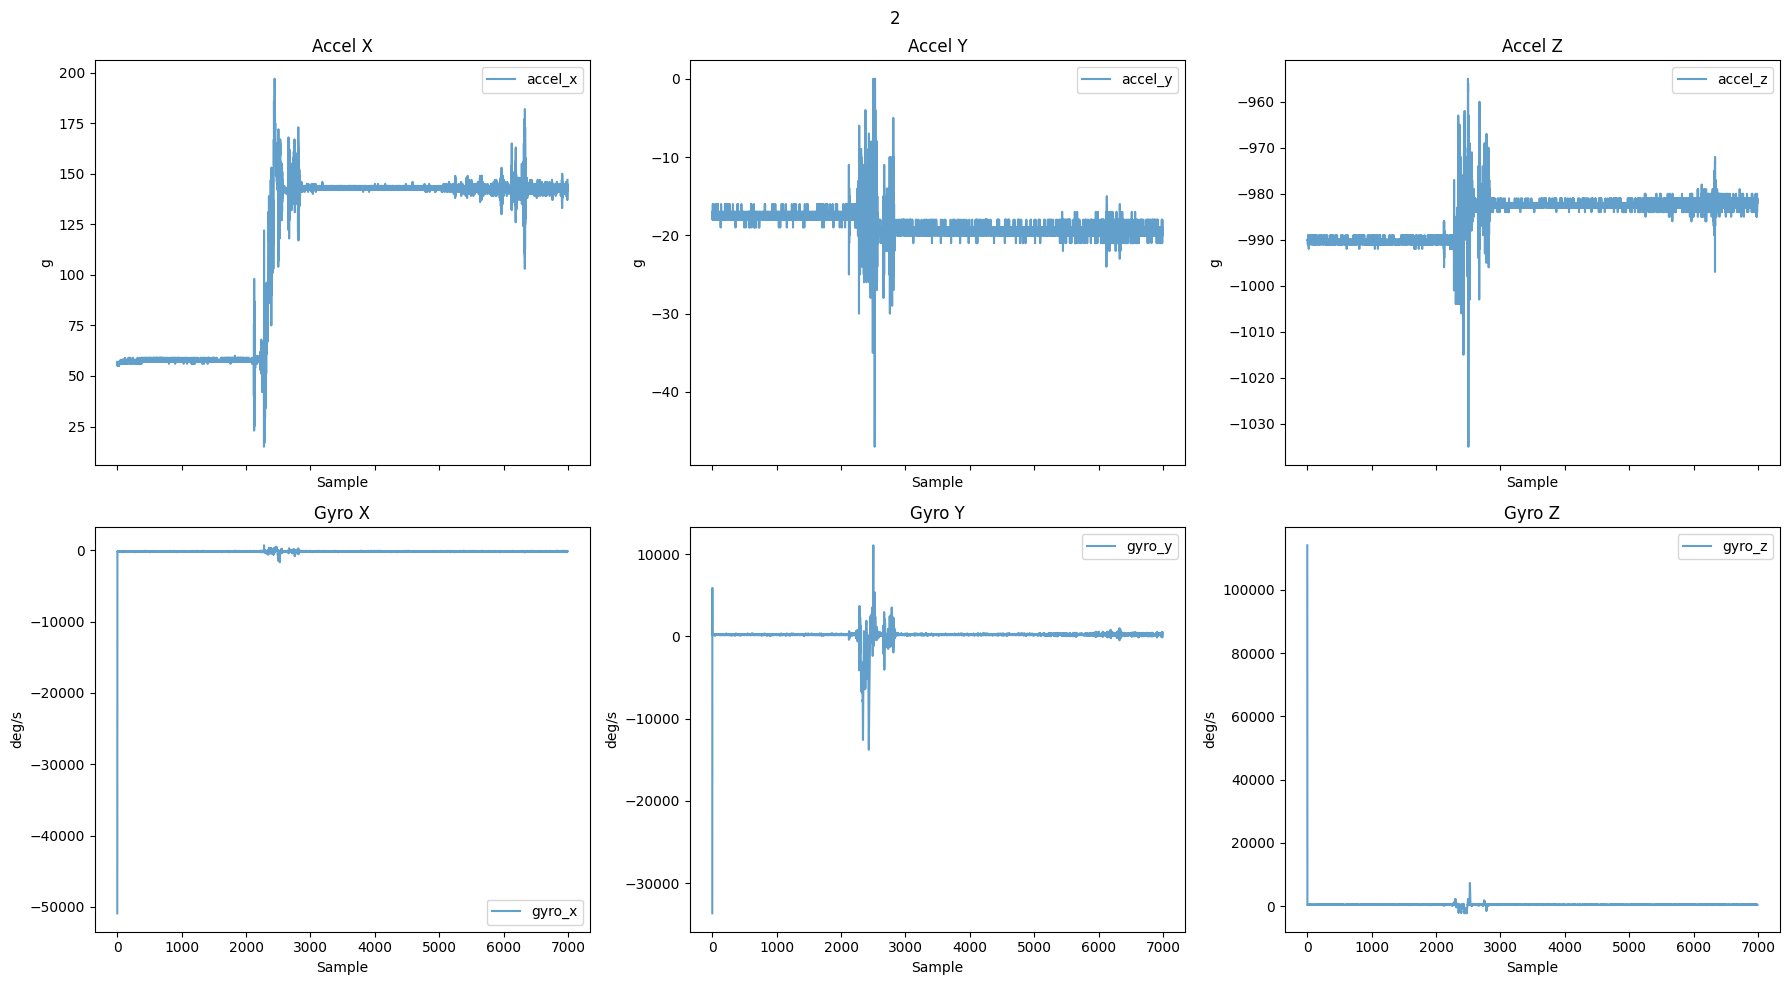

In [65]:
segments = [segments[2]]
for segment in segments:
    test_id, data, start_idx, end_idx = segment.values()
    plot_raw(data, title=test_id)

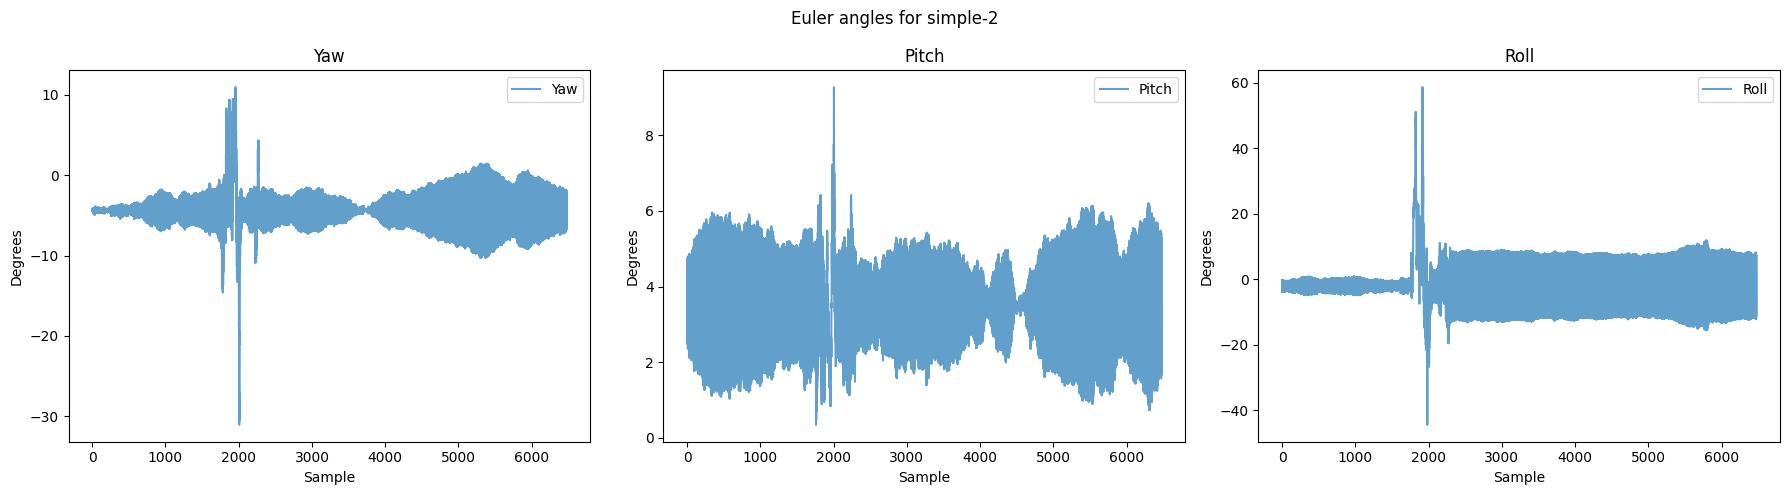

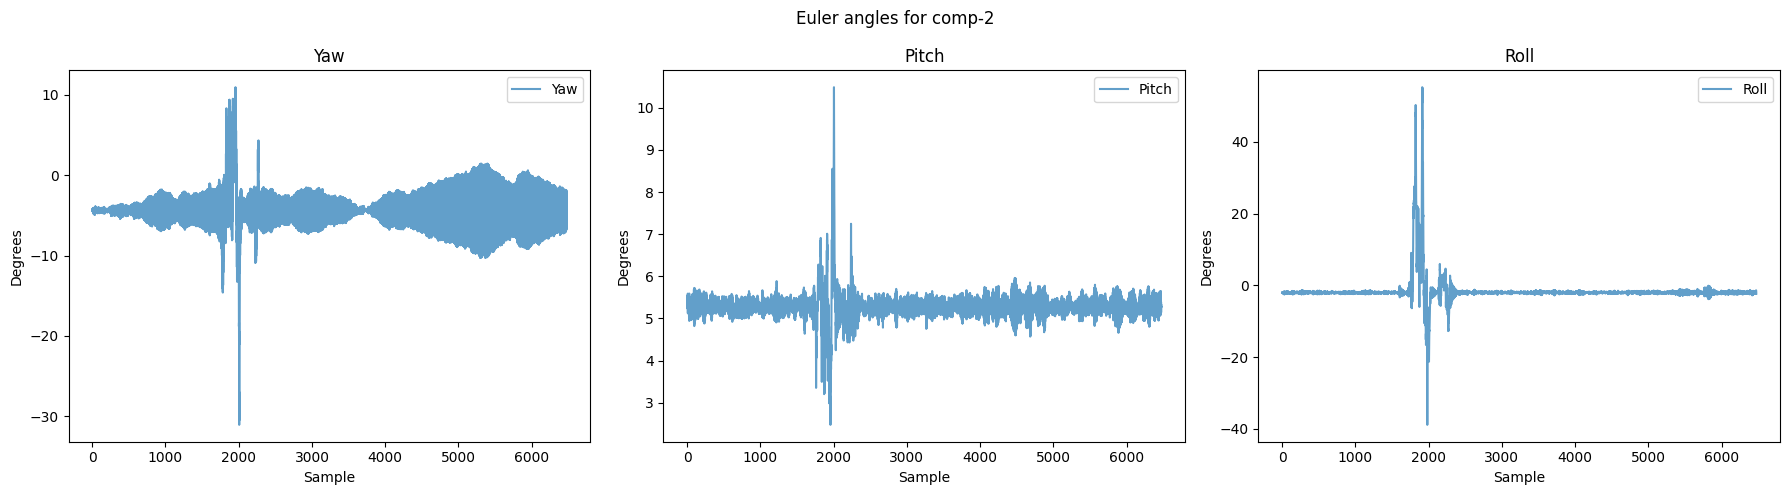

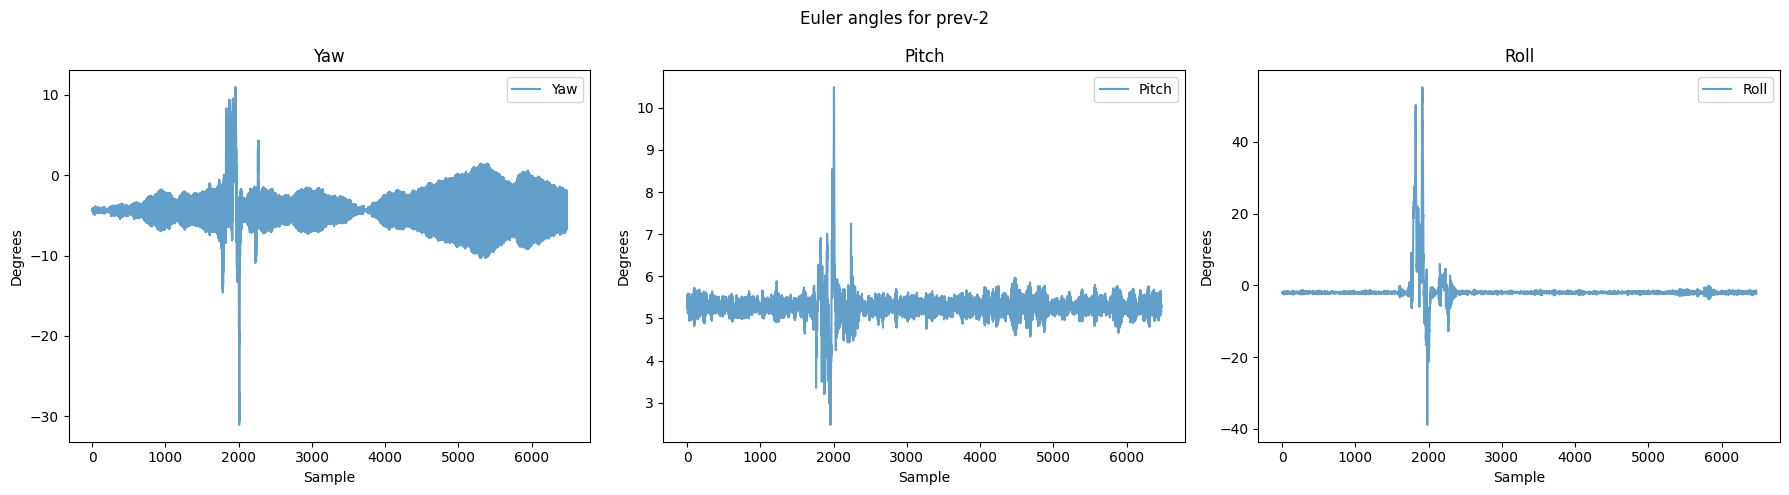

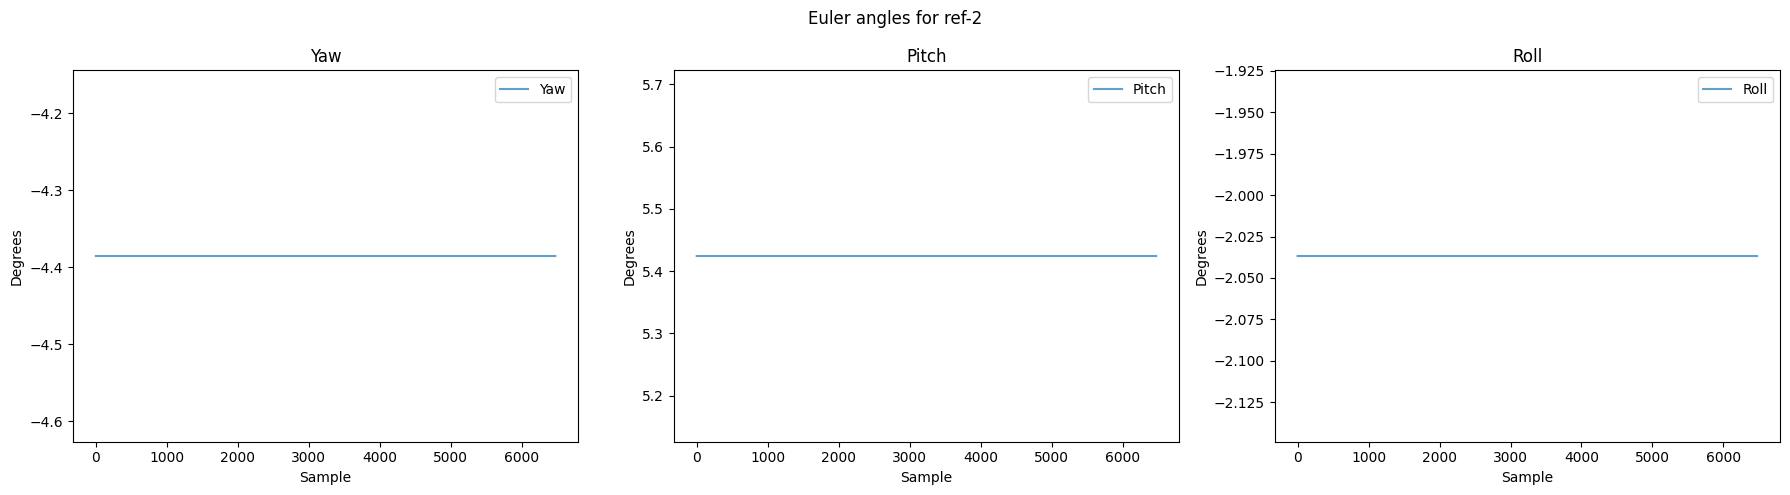

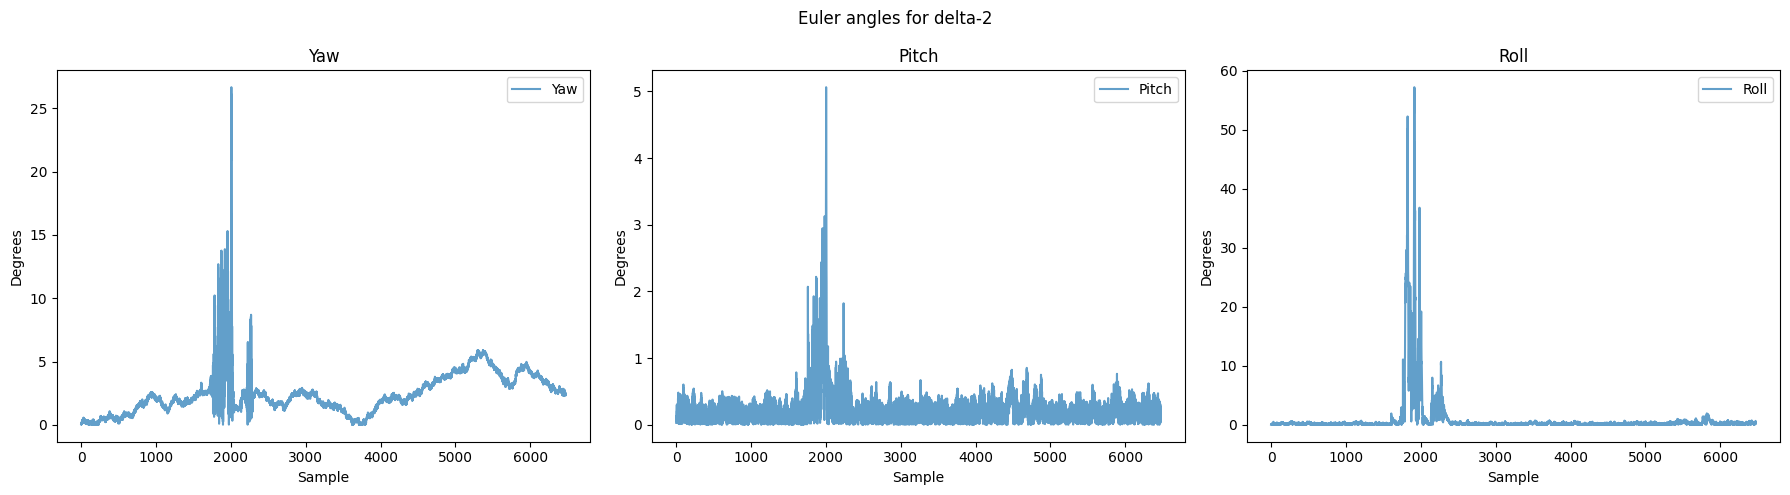

In [66]:
segment_results = {2:segment_results[2]}
for segment_id, results in segment_results.items():
    for title,arr in results.items():
        plot_angles(arr[0], arr[1], arr[2], title=f"Euler angles for {title}-{segment_id}")

In [67]:
def analyze_filter_performance(results):
    """Analyze filter performance metrics"""
    metrics = {}
    
    # Compute spectral characteristics
    for name, angles in results.items():
        if name != 'delta':
            yaw, pitch, roll = angles
            metrics[f'{name}_yaw_rms'] = np.sqrt(np.mean(yaw**2))
            metrics[f'{name}_yaw_drift'] = np.polyfit(range(len(yaw)), yaw, 1)[0]
            
            metrics[f'{name}_pitch_rms'] = np.sqrt(np.mean(pitch**2))
            metrics[f'{name}_pitch_drift'] = np.polyfit(range(len(pitch)), pitch, 1)[0]

            metrics[f'{name}_roll_rms'] = np.sqrt(np.mean(roll**2))
            metrics[f'{name}_roll_drift'] = np.polyfit(range(len(roll)), roll, 1)[0]
    return metrics

In [68]:
analyze_filter_performance(results)

{'simple_yaw_rms': np.float64(5.30703455123334),
 'simple_yaw_drift': np.float64(-2.2464671318009727e-05),
 'simple_pitch_rms': np.float64(3.8520630845515247),
 'simple_pitch_drift': np.float64(-1.70800904660295e-06),
 'simple_roll_rms': np.float64(9.489450508081886),
 'simple_roll_drift': np.float64(-0.00016717637464007255),
 'comp_yaw_rms': np.float64(5.30703455123334),
 'comp_yaw_drift': np.float64(-2.2464671318009727e-05),
 'comp_pitch_rms': np.float64(5.287378024638099),
 'comp_pitch_drift': np.float64(-1.648645448976142e-06),
 'comp_roll_rms': np.float64(4.403530422629265),
 'comp_roll_drift': np.float64(-0.00016005069301487703),
 'prev_yaw_rms': np.float64(5.30703455123334),
 'prev_yaw_drift': np.float64(-2.2464671318009727e-05),
 'prev_pitch_rms': np.float64(5.287378024638099),
 'prev_pitch_drift': np.float64(-1.648645448976142e-06),
 'prev_roll_rms': np.float64(4.403530422629265),
 'prev_roll_drift': np.float64(-0.00016005069301487703),
 'ref_yaw_rms': np.float64(4.38551076076